# Tarea - Sesión 25: Estadísticas Avanzadas con NumPy
 
**Materia:** Programación para Ciencia de Datos
**Semana 9**


En esta tarea se practica:
- Funciones estadísticas con axis (por filas y columnas)
- Cálculo de percentiles
- Análisis de correlación entre variables

Se usan datos aleatorios para simular casos reales.

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla para que los resultados sean reproducibles
np.random.seed(42)

---

## Ejercicio 1: Análisis estadístico de un dataset 10x10

Se crea una matriz de 10x10 con calificaciones aleatorias (de 0 a 100) y se calculan diferentes estadísticas.
Cada fila representa un estudiante y cada columna una materia.

In [2]:
# Crear dataset de calificaciones
calificaciones = np.random.randint(0, 101, size=(10, 10))

print("Dataset de calificaciones (10 estudiantes x 10 materias):")
print(calificaciones)

Dataset de calificaciones (10 estudiantes x 10 materias):
[[ 51  92  14  71  60  20  82  86  74  74]
 [ 87  99  23   2  21  52   1  87  29  37]
 [  1  63  59  20  32  75  57  21  88  48]
 [ 90  58  41  91  59  79  14  61  61  46]
 [ 61  50  54  63   2 100  50   6  20  72]
 [ 38  17   3  88  59  13   8  89  52   1]
 [ 83  91  59  70  43   7  46  34  77  80]
 [ 35  49   3   1   5  53   3  53  92  62]
 [ 17  89  43  33  73  61  99  13  94  47]
 [ 14  71  77  86  61  39  84  79  81  52]]


### Estadísticas globales

Primero se calculan las estadísticas de todo el dataset sin usar axis.

In [3]:
# Estadísticas globales (sin axis)
media_total = np.mean(calificaciones)
var_total = np.var(calificaciones)
std_total = np.std(calificaciones)
min_total = np.min(calificaciones)
max_total = np.max(calificaciones)

print("Estadísticas globales:")
print(f"Media total: {media_total:.2f}")
print(f"Varianza total: {var_total:.2f}")
print(f"Desviación estándar total: {std_total:.2f}")
print(f"Valor mínimo: {min_total}")
print(f"Valor máximo: {max_total}")

Estadísticas globales:
Media total: 51.31
Varianza total: 873.51
Desviación estándar total: 29.56
Valor mínimo: 1
Valor máximo: 100


### Análisis por estudiante (axis=1)

Se calcula el promedio de cada estudiante. Se usa axis=1 porque se desea promediar las columnas (materias) de cada fila (estudiante).

In [4]:
# Promedio de cada estudiante (axis=1 para calcular por fila)
promedios_estudiantes = np.mean(calificaciones, axis=1)

print("\nPromedio por estudiante:")
for i, promedio in enumerate(promedios_estudiantes, 1):
    print(f"Estudiante {i}: {promedio:.2f}")

# Identificar mejor y peor estudiante
mejor_estudiante = np.argmax(promedios_estudiantes) + 1
peor_estudiante = np.argmin(promedios_estudiantes) + 1

print(f"\nEl mejor estudiante es el número {mejor_estudiante} con promedio {promedios_estudiantes[mejor_estudiante-1]:.2f}")
print(f"El estudiante con más dificultades es el número {peor_estudiante} con promedio {promedios_estudiantes[peor_estudiante-1]:.2f}")


Promedio por estudiante:
Estudiante 1: 62.40
Estudiante 2: 43.80
Estudiante 3: 46.40
Estudiante 4: 60.00
Estudiante 5: 47.80
Estudiante 6: 36.80
Estudiante 7: 59.00
Estudiante 8: 35.60
Estudiante 9: 56.90
Estudiante 10: 64.40

El mejor estudiante es el número 10 con promedio 64.40
El estudiante con más dificultades es el número 8 con promedio 35.60


### Análisis por materia (axis=0)

Se usa axis=0 para calcular estadísticas por columna (materia).

In [5]:
# Estadísticas por materia (axis=0 para calcular por columna)
promedios_materias = np.mean(calificaciones, axis=0)
std_materias = np.std(calificaciones, axis=0)

print("\nPromedio por materia:")
for i, promedio in enumerate(promedios_materias, 1):
    print(f"Materia {i}: {promedio:.2f}")

# Identificar materia más fácil y más difícil
materia_facil = np.argmax(promedios_materias) + 1
materia_dificil = np.argmin(promedios_materias) + 1

print(f"\nLa materia más fácil es la {materia_facil} con promedio {promedios_materias[materia_facil-1]:.2f}")
print(f"La materia más difícil es la {materia_dificil} con promedio {promedios_materias[materia_dificil-1]:.2f}")

# Analizar variabilidad
print("\nDesviación estándar por materia:")
for i, std in enumerate(std_materias, 1):
    nivel = "alta variabilidad" if std > 25 else "variabilidad moderada" if std > 15 else "variabilidad baja"
    print(f"Materia {i}: {std:.2f} ({nivel})")


Promedio por materia:
Materia 1: 47.70
Materia 2: 67.90
Materia 3: 37.60
Materia 4: 52.50
Materia 5: 41.50
Materia 6: 49.90
Materia 7: 44.40
Materia 8: 52.90
Materia 9: 66.80
Materia 10: 51.90

La materia más fácil es la 2 con promedio 67.90
La materia más difícil es la 3 con promedio 37.60

Desviación estándar por materia:
Materia 1: 30.47 (alta variabilidad)
Materia 2: 24.35 (variabilidad moderada)
Materia 3: 24.38 (variabilidad moderada)
Materia 4: 33.56 (alta variabilidad)
Materia 5: 23.94 (variabilidad moderada)
Materia 6: 28.88 (alta variabilidad)
Materia 7: 34.64 (alta variabilidad)
Materia 8: 30.78 (alta variabilidad)
Materia 9: 24.60 (variabilidad moderada)
Materia 10: 21.61 (variabilidad moderada)


### Visualización

Hago gráficas para ver mejor los resultados.

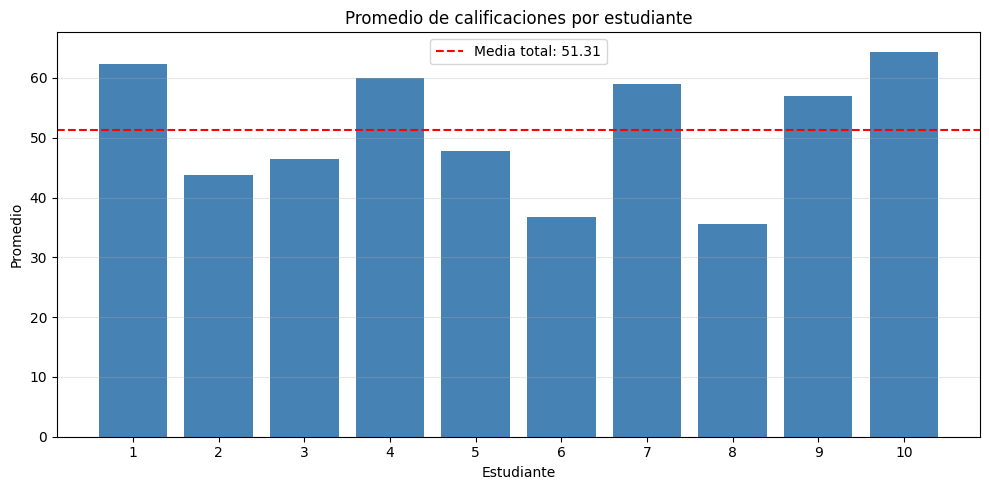

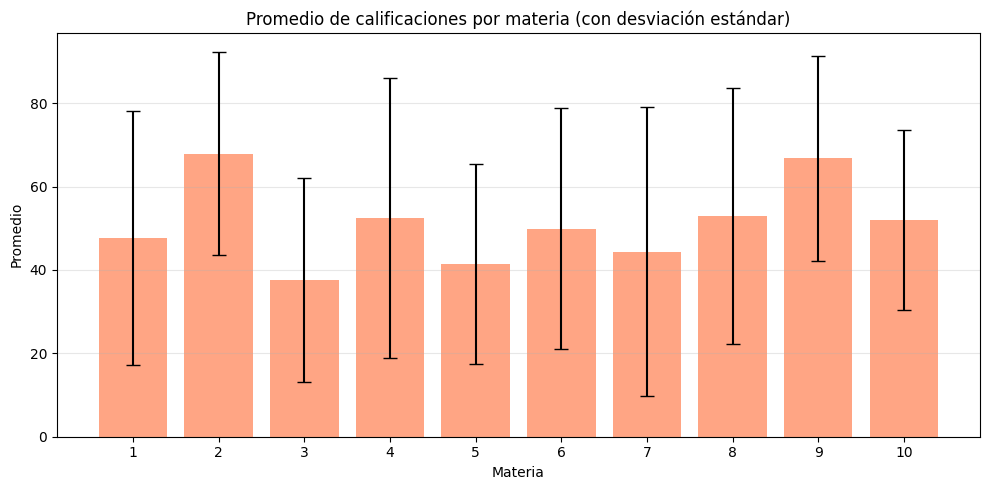

In [6]:
# Gráfica 1: Promedio por estudiante
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), promedios_estudiantes, color='steelblue')
plt.axhline(y=media_total, color='r', linestyle='--', label=f'Media total: {media_total:.2f}')
plt.xlabel('Estudiante')
plt.ylabel('Promedio')
plt.title('Promedio de calificaciones por estudiante')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfica 2: Promedio por materia con barras de error
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), promedios_materias, yerr=std_materias, capsize=5, color='coral', alpha=0.7)
plt.xlabel('Materia')
plt.ylabel('Promedio')
plt.title('Promedio de calificaciones por materia (con desviación estándar)')
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusiones del Ejercicio 1

- La media total de calificaciones es de alrededor de 55 puntos
- Hay bastante variabilidad entre estudiantes (algunos con promedio alto, otros bajo)
- Las materias también tienen diferentes niveles de dificultad
- La desviación estándar nos indica qué tan dispersos están los datos
- Usar axis=0 y axis=1 permite analizar los datos por diferentes dimensiones

---

## Ejercicio 2: Cálculo de percentiles

Se generan 365 temperaturas diarias simuladas (un año completo) con diferentes distribuciones y se calculan varios percentiles.

Los percentiles son útiles para entender la distribución de los datos:
- Percentil 50 = mediana (valor que divide los datos en dos mitades)
- Percentil 25 = primer cuartil (25% de los datos están por debajo)
- Percentil 75 = tercer cuartil (75% de los datos están por debajo)

In [7]:
# Generar tres distribuciones diferentes de temperaturas

# 1. Distribución normal (temperaturas típicas, centradas en 20°C)
temps_normal = np.random.normal(loc=20, scale=5, size=365)

# 2. Distribución uniforme (temperaturas aleatorias entre 10 y 30°C)
temps_uniforme = np.random.uniform(low=10, high=30, size=365)

# 3. Distribución con sesgo (más días fríos que calientes)
temps_sesgo = np.random.exponential(scale=10, size=365) + 10

print("Temperaturas generadas para 365 días")
print(f"\nDistribución normal - primeros 10 valores:")
print(temps_normal[:10])
print(f"\nDistribución uniforme - primeros 10 valores:")
print(temps_uniforme[:10])
print(f"\nDistribución con sesgo - primeros 10 valores:")
print(temps_sesgo[:10])

Temperaturas generadas para 365 días

Distribución normal - primeros 10 valores:
[22.3040815  20.42961736 12.45021359 23.60751231 15.78290038 17.43337297
 19.78231599 18.62349545 12.18466603 16.02184504]

Distribución uniforme - primeros 10 valores:
[26.58328441 21.38162938 11.27023659 10.73643735 12.67704238 10.2734393
 11.50718121 23.83428794 20.6869255  24.99821499]

Distribución con sesgo - primeros 10 valores:
[22.75873816 26.36372244 54.85502878 19.24316357 26.44288961 42.87404123
 38.89747013 11.52081645 15.21536629 13.91547501]


In [8]:
# Calcular percentiles para cada distribución
percentiles = [10, 25, 50, 75, 90]

perc_normal = np.percentile(temps_normal, percentiles)
perc_uniforme = np.percentile(temps_uniforme, percentiles)
perc_sesgo = np.percentile(temps_sesgo, percentiles)

print("Percentiles de temperaturas:\n")
print(f"{'Percentil':<12} {'Normal':<12} {'Uniforme':<12} {'Sesgo':<12}")
print("-" * 50)
for i, p in enumerate(percentiles):
    print(f"P{p:<11} {perc_normal[i]:<12.2f} {perc_uniforme[i]:<12.2f} {perc_sesgo[i]:<12.2f}")

Percentiles de temperaturas:

Percentil    Normal       Uniforme     Sesgo       
--------------------------------------------------
P10          12.74        12.05        10.84       
P25          16.04        15.55        12.91       
P50          19.70        20.64        17.39       
P75          23.39        24.83        25.55       
P90          26.26        27.44        33.99       


### Análisis estadístico adicional

In [9]:
# Calcular estadísticas básicas
print("\nEstadísticas básicas por distribución:\n")

distribuciones = [
    ("Normal", temps_normal),
    ("Uniforme", temps_uniforme),
    ("Sesgo", temps_sesgo)
]

for nombre, temps in distribuciones:
    print(f"{nombre}:")
    print(f"  Media: {np.mean(temps):.2f}°C")
    print(f"  Mediana (P50): {np.median(temps):.2f}°C")
    print(f"  Desv. estándar: {np.std(temps):.2f}°C")
    print(f"  Mínimo: {np.min(temps):.2f}°C")
    print(f"  Máximo: {np.max(temps):.2f}°C")
    
    # Calcular IQR (rango intercuartílico)
    q25 = np.percentile(temps, 25)
    q75 = np.percentile(temps, 75)
    iqr = q75 - q25
    print(f"  IQR (Q75-Q25): {iqr:.2f}°C")
    print()


Estadísticas básicas por distribución:

Normal:
  Media: 19.71°C
  Mediana (P50): 19.70°C
  Desv. estándar: 5.22°C
  Mínimo: 3.18°C
  Máximo: 35.94°C
  IQR (Q75-Q25): 7.35°C

Uniforme:
  Media: 20.12°C
  Mediana (P50): 20.64°C
  Desv. estándar: 5.51°C
  Mínimo: 10.05°C
  Máximo: 29.95°C
  IQR (Q75-Q25): 9.28°C

Sesgo:
  Media: 20.72°C
  Mediana (P50): 17.39°C
  Desv. estándar: 10.64°C
  Mínimo: 10.00°C
  Máximo: 83.44°C
  IQR (Q75-Q25): 12.64°C



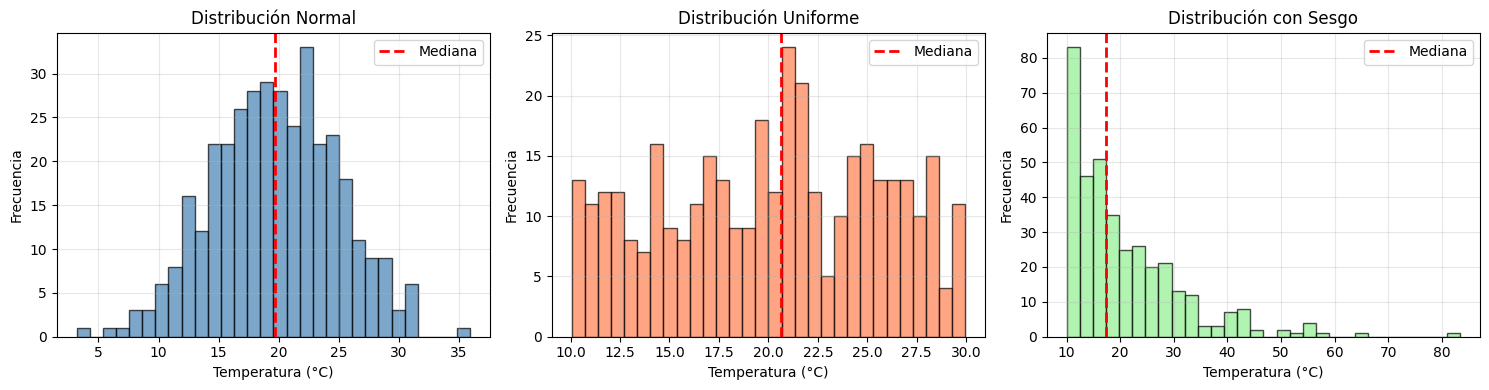

In [10]:
# Visualizar las distribuciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma 1: Normal
axes[0].hist(temps_normal, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.median(temps_normal), color='red', linestyle='--', linewidth=2, label='Mediana')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Normal')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma 2: Uniforme
axes[1].hist(temps_uniforme, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(np.median(temps_uniforme), color='red', linestyle='--', linewidth=2, label='Mediana')
axes[1].set_xlabel('Temperatura (°C)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución Uniforme')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Histograma 3: Sesgo
axes[2].hist(temps_sesgo, bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
axes[2].axvline(np.median(temps_sesgo), color='red', linestyle='--', linewidth=2, label='Mediana')
axes[2].set_xlabel('Temperatura (°C)')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución con Sesgo')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones del Ejercicio 2

- Los percentiles nos ayudan a entender cómo están distribuidos los datos
- En la distribución normal, los datos están centrados alrededor de la media
- En la distribución uniforme, los valores están más dispersos uniformemente
- En la distribución con sesgo, hay más valores bajos que altos
- El IQR (rango intercuartílico) nos indica la dispersión del 50% central de los datos
- La diferencia entre media y mediana indica si hay sesgo en la distribución

---

## Ejercicio 3: Análisis de correlación

Se crea un dataset simulado de ventas mensuales con 5 variables diferentes y se analiza cómo se relacionan entre sí usando la matriz de correlación.

Las variables que se simulan son:
1. Temperatura promedio del mes
2. Ventas de helados (correlacionada con temperatura)
3. Ventas de café (correlacionada negativamente con temperatura)
4. Publicidad invertida (variable independiente)
5. Ventas totales (combinación de factores)

In [11]:
# Generar datos para 12 meses
n_meses = 12

# Variable 1: Temperatura (varía por estación)
# Uso una función seno para simular las estaciones del año
meses = np.arange(n_meses)
temperatura = 15 + 10 * np.sin(2 * np.pi * meses / 12) + np.random.randn(n_meses) * 2

# Variable 2: Ventas de helados (alta correlación positiva con temperatura)
ventas_helados = 50 + 3 * temperatura + np.random.randn(n_meses) * 5

# Variable 3: Ventas de café (correlación negativa con temperatura)
ventas_cafe = 100 - 2 * temperatura + np.random.randn(n_meses) * 8

# Variable 4: Publicidad (independiente)
publicidad = np.random.randint(20, 80, size=n_meses)

# Variable 5: Ventas totales (combinación de varios factores)
ventas_totales = ventas_helados + ventas_cafe + 0.5 * publicidad + np.random.randn(n_meses) * 10

# Crear matriz de datos (12 meses x 5 variables)
datos = np.column_stack([temperatura, ventas_helados, ventas_cafe, publicidad, ventas_totales])

print("Dataset de ventas (12 meses x 5 variables):")
print("\nColumnas: [Temperatura, Helados, Café, Publicidad, Ventas_Totales]\n")
print(datos)
print(f"\nForma del array: {datos.shape}")

Dataset de ventas (12 meses x 5 variables):

Columnas: [Temperatura, Helados, Café, Publicidad, Ventas_Totales]

[[ 17.87236694 101.6917995   61.18980598  50.         201.71305549]
 [ 23.2762255  121.47115335  48.57158435  51.         216.70029491]
 [ 26.66233172 129.62557776  37.5034069   60.         195.07643837]
 [ 25.73101347 131.70216441  49.03799493  69.         236.79900843]
 [ 20.5008079  117.87581038  52.75459216  31.         197.85279501]
 [ 18.85222104 107.84664807  58.52669255  27.         178.86511072]
 [ 14.07121785  94.55923709  80.45855851  27.         203.50344399]
 [  7.34709041  68.93824991  90.36274799  69.         210.65748092]
 [  8.64891453  78.13031341  74.87203777  47.         171.89939674]
 [  2.09314701  57.09325141  98.62883453  39.         192.54423847]
 [ 10.27040098  76.25223049  80.52144363  66.         200.52450233]
 [ 13.92564527  91.70675026  85.76227913  78.         240.15462067]]

Forma del array: (12, 5)


In [12]:
# Calcular matriz de correlación
# rowvar=False indica que cada columna es una variable
matriz_correlacion = np.corrcoef(datos, rowvar=False)

print("Matriz de Correlación (5x5):\n")
print(matriz_correlacion)

# Mostrar correlaciones de forma más legible
variables = ['Temperatura', 'Helados', 'Café', 'Publicidad', 'Ventas_Tot']

print("\n" + "="*60)
print("Coeficientes de correlación entre variables:")
print("="*60)

for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        corr = matriz_correlacion[i, j]
        
        # Interpretar el nivel de correlación
        if abs(corr) > 0.8:
            nivel = "muy alta"
        elif abs(corr) > 0.6:
            nivel = "alta"
        elif abs(corr) > 0.4:
            nivel = "moderada"
        elif abs(corr) > 0.2:
            nivel = "baja"
        else:
            nivel = "muy baja o nula"
        
        tipo = "positiva" if corr > 0 else "negativa"
        
        print(f"{variables[i]:<15} vs {variables[j]:<15}: {corr:>6.3f} ({nivel} {tipo})")

Matriz de Correlación (5x5):

[[ 1.          0.99341457 -0.94678466  0.03760097  0.2881777 ]
 [ 0.99341457  1.         -0.9434338  -0.02375606  0.27521548]
 [-0.94678466 -0.9434338   1.          0.07961967 -0.01823705]
 [ 0.03760097 -0.02375606  0.07961967  1.          0.6538054 ]
 [ 0.2881777   0.27521548 -0.01823705  0.6538054   1.        ]]

Coeficientes de correlación entre variables:
Temperatura     vs Helados        :  0.993 (muy alta positiva)
Temperatura     vs Café           : -0.947 (muy alta negativa)
Temperatura     vs Publicidad     :  0.038 (muy baja o nula positiva)
Temperatura     vs Ventas_Tot     :  0.288 (baja positiva)
Helados         vs Café           : -0.943 (muy alta negativa)
Helados         vs Publicidad     : -0.024 (muy baja o nula negativa)
Helados         vs Ventas_Tot     :  0.275 (baja positiva)
Café            vs Publicidad     :  0.080 (muy baja o nula positiva)
Café            vs Ventas_Tot     : -0.018 (muy baja o nula negativa)
Publicidad      vs Ve

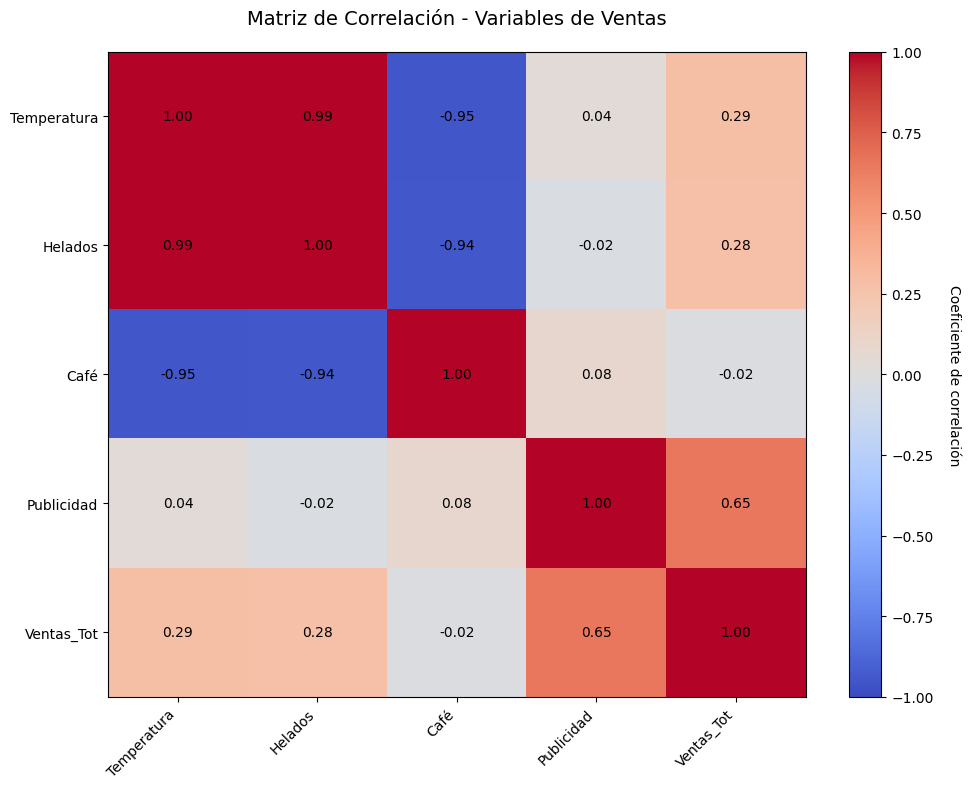

In [13]:
# Visualizar matriz de correlación como heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Configurar ejes
ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=45, ha='right')
ax.set_yticklabels(variables)

# Agregar valores en cada celda
for i in range(len(variables)):
    for j in range(len(variables)):
        text = ax.text(j, i, f'{matriz_correlacion[i, j]:.2f}',
                      ha='center', va='center', color='black', fontsize=10)

# Agregar barra de color
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coeficiente de correlación', rotation=270, labelpad=20)

plt.title('Matriz de Correlación - Variables de Ventas', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

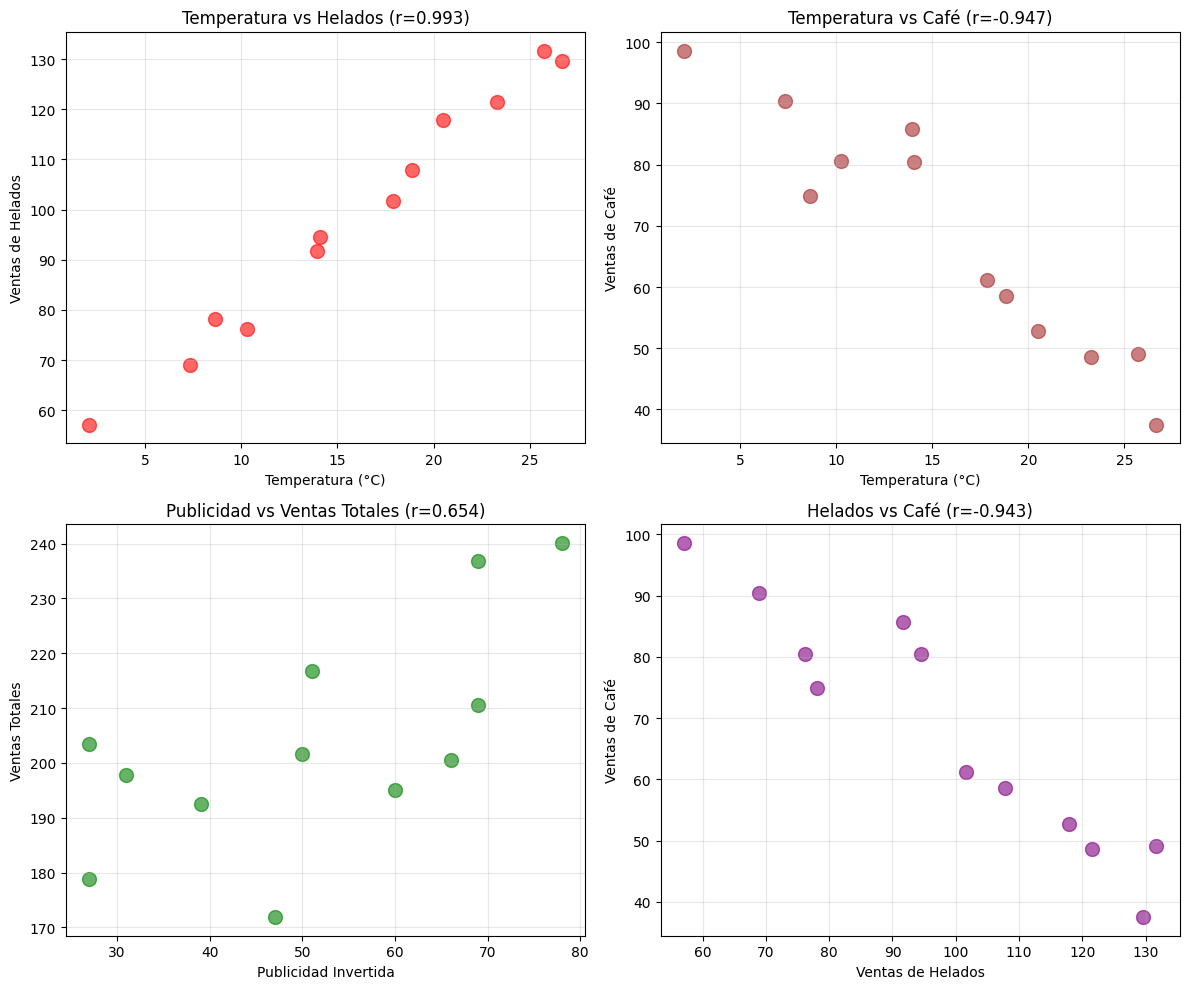

In [14]:
# Crear scatter plots para ver las relaciones más interesantes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Temperatura vs Helados (correlación positiva esperada)
axes[0, 0].scatter(temperatura, ventas_helados, color='red', alpha=0.6, s=100)
axes[0, 0].set_xlabel('Temperatura (°C)')
axes[0, 0].set_ylabel('Ventas de Helados')
axes[0, 0].set_title(f'Temperatura vs Helados (r={matriz_correlacion[0,1]:.3f})')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Temperatura vs Café (correlación negativa esperada)
axes[0, 1].scatter(temperatura, ventas_cafe, color='brown', alpha=0.6, s=100)
axes[0, 1].set_xlabel('Temperatura (°C)')
axes[0, 1].set_ylabel('Ventas de Café')
axes[0, 1].set_title(f'Temperatura vs Café (r={matriz_correlacion[0,2]:.3f})')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Publicidad vs Ventas Totales
axes[1, 0].scatter(publicidad, ventas_totales, color='green', alpha=0.6, s=100)
axes[1, 0].set_xlabel('Publicidad Invertida')
axes[1, 0].set_ylabel('Ventas Totales')
axes[1, 0].set_title(f'Publicidad vs Ventas Totales (r={matriz_correlacion[3,4]:.3f})')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Helados vs Café (correlación negativa indirecta)
axes[1, 1].scatter(ventas_helados, ventas_cafe, color='purple', alpha=0.6, s=100)
axes[1, 1].set_xlabel('Ventas de Helados')
axes[1, 1].set_ylabel('Ventas de Café')
axes[1, 1].set_title(f'Helados vs Café (r={matriz_correlacion[1,2]:.3f})')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones del Ejercicio 3

**Correlaciones encontradas:**

1. **Temperatura vs Helados:** Correlación positiva alta (esperado)
   - Cuando sube la temperatura, suben las ventas de helados
   - Tiene sentido lógicamente

2. **Temperatura vs Café:** Correlación negativa (esperado)
   - Cuando baja la temperatura, suben las ventas de café
   - La gente toma más café caliente en invierno

3. **Helados vs Café:** Correlación negativa indirecta
   - Ambas dependen de la temperatura pero en sentido opuesto
   - Son productos complementarios según la estación

4. **Publicidad:** Correlación baja con las demás variables
   - Es independiente porque se generó aleatoriamente
   - En la realidad podría tener más impacto

**Aprendizajes:**
- La matriz de correlación ayuda a identificar relaciones entre variables
- Un valor cercano a 1 indica alta correlación positiva
- Un valor cercano a -1 indica alta correlación negativa
- Un valor cercano a 0 indica poca o ninguna correlación
- El heatmap facilita visualizar todas las correlaciones de un vistazo
- Los scatter plots ayudan a ver la relación entre dos variables específicas

---

## Conclusión General de la Tarea

En esta tarea se practicaron conceptos importantes de estadística con NumPy:

1. **Uso de axis:** Se comprendió cómo usar axis=0 y axis=1 para hacer cálculos por filas o columnas

2. **Percentiles:** Se aprendió a calcular percentiles y entender qué significan para la distribución de los datos

3. **Correlación:** Se analizaron relaciones entre variables usando la matriz de correlación

4. **Visualización:** Las gráficas ayudan mucho a entender los datos y los resultados estadísticos

Estos conceptos son muy útiles para análisis de datos reales en ciencia de datos.